# Geometry Separation of Ground-Truth 0 vs 1 Scans from Mongo

This notebook analyzes whether the geometry of saved scans consistently differs between `ground_truth=0` and `ground_truth=1`.

It focuses on:
- direct geometry metrics per layer: centroid shift, spread, Fisher-style separation, energy distance, MMD, and subspace similarity
- stability checks: stratified CV, balanced subsamples, bootstrap confidence intervals
- trajectory-level analysis: per-layer AUC, cumulative AUC, prototype-distance separation, optional DTW, and 2D trajectory visualization

Use `LAYER_NAME_FILTER = "SelfAttention.o"` for attention outputs or `"DenseReluDense.wo"` for FF activation outputs.

In [1]:
import os
import sys
import tempfile

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import pairwise_distances, rbf_kernel

from neuralsignal.backend.ns_backend import NSBackend
from neuralsignal.core.modules.neuralsignal_config import sdk_config

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Mongo / dataset config
APPLICATION_NAME = "HaluBench"
SUB_APPLICATION_NAME = "GranularAttentioAndWO"

# APPLICATION_NAME = "redis"
# SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

# Extra filters beyond ground truth. Keep empty if not needed.
BASE_QUERY = {}
GROUND_TRUTH_0_QUERY = {"ground_truth": {"$in": [0, "0", False]}}
GROUND_TRUTH_1_QUERY = {"ground_truth": {"$in": [1, "1", True]}}

# Analysis target
LAYER_NAME_FILTER = "DenseReluDense.wo"   # or "DenseReluDense.wo"
TOKEN_SELECTION = "last"                # one of: last, mean

# Sampling / compute limits
MAX_SCANS_PER_CLASS = 50
RANDOM_STATE = 7
CV_FOLDS = 5
BALANCED_SUBSAMPLE_ROUNDS = 32
BOOTSTRAP_ROUNDS = 64
SUBSPACE_COMPONENTS = 5
PER_LAYER_PCA_COMPONENTS = 16
CUMULATIVE_PCA_COMPONENTS = 32
RUN_DTW_TRAJECTORY = False

LABEL_0 = "ground_truth=0"
LABEL_1 = "ground_truth=1"

In [3]:
backend_cfg = sdk_config.get_backend_config().copy()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def merged_query(*parts):
    out = {}
    for p in parts:
        out.update(p)
    return out

def load_scans_by_query(ns_backend, query, limit=0):
    cursor = ns_backend.query(query)
    if limit and limit > 0:
        cursor = cursor.limit(limit)
    scans = []
    skipped = 0
    for doc in cursor:
        try:
            scans.append(ns_backend.deserialize_scan(doc))
        except Exception:
            skipped += 1
    return scans, skipped

query_0 = merged_query(BASE_QUERY, GROUND_TRUTH_0_QUERY)
query_1 = merged_query(BASE_QUERY, GROUND_TRUTH_1_QUERY)

group_0, skipped_0 = load_scans_by_query(be, query_0, MAX_SCANS_PER_CLASS)
group_1, skipped_1 = load_scans_by_query(be, query_1, MAX_SCANS_PER_CLASS)

print(f"{LABEL_0}: loaded {len(group_0)} scans  (skipped {skipped_0})")
print(f"{LABEL_1}: loaded {len(group_1)} scans  (skipped {skipped_1})")
print(f"Layer filter: {LAYER_NAME_FILTER}")

ground_truth=0: loaded 50 scans  (skipped 0)
ground_truth=1: loaded 50 scans  (skipped 0)
Layer filter: DenseReluDense.wo


In [4]:
def get_mongo_backend(ns_backend):
    backend = ns_backend.backend
    if hasattr(backend, "col"):
        return backend
    if hasattr(backend, "mng"):
        return backend.mng
    raise TypeError("Configured backend does not expose a Mongo collection.")

mongo_backend = get_mongo_backend(be)
print(f"Mongo db         : {mongo_backend.db.name}")
print(f"Mongo collection : {mongo_backend.col.name}")
print(f"Total docs       : {mongo_backend.col.count_documents({})}")
print(f"Class-0 query ct : {mongo_backend.col.count_documents(query_0)}")
print(f"Class-1 query ct : {mongo_backend.col.count_documents(query_1)}")

sample_docs = list(mongo_backend.col.find({}, {"ground_truth": 1, "decoded_output": 1, "metadata": 1}).limit(5))
sample_docs

Mongo db         : HaluBench
Mongo collection : GranularAttentioAndWO
Total docs       : 1000
Class-0 query ct : 500
Class-1 query ct : 500


[{'_id': ObjectId('69bf0e32ad24d9148050eba0'),
  'ground_truth': 0,
  'decoded_output': 'false',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e35ad24d9148050ee31'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e39ad24d9148050f116'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e3cad24d9148050f418'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e3fad24d9148050f6b4'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}}]

In [5]:
rng = np.random.default_rng(RANDOM_STATE)

def vectorize_tensor(tensor, token_selection="last"):
    t = tensor.float().cpu()
    if t.ndim == 1:
        return t.numpy()
    if t.ndim != 2:
        raise ValueError(f"Expected 1D or 2D tensor, got shape {tuple(t.shape)}")
    if token_selection == "last":
        return t[-1].numpy()
    if token_selection == "mean":
        return t.mean(dim=0).numpy()
    raise ValueError(f"Unsupported TOKEN_SELECTION={token_selection}")

def get_matching_layers(scan, layer_name_filter):
    matches = []
    for layer_id in scan["layer_order"]:
        layer_name = scan["layer_id_to_name"][layer_id]
        if layer_name_filter in layer_name:
            matches.append((layer_id, layer_name, f"L{len(matches):02d}"))
    if not matches:
        raise ValueError(f"No layers matched filter '{layer_name_filter}'")
    return matches

def build_scan_tensor(scans, expected_layers, token_selection="last"):
    valid = []
    ids = []
    dropped = 0
    target_dim = None
    for scan in scans:
        try:
            rows = []
            for layer_id, _, _ in expected_layers:
                vec = vectorize_tensor(scan["outputs"][layer_id], token_selection=token_selection)
                rows.append(vec)
            mat = np.stack(rows, axis=0)
            if target_dim is None:
                target_dim = mat.shape[1]
            if mat.shape[1] != target_dim:
                dropped += 1
                continue
            valid.append(mat)
            ids.append(str(scan.get("_id", len(ids))))
        except Exception:
            dropped += 1
    if not valid:
        raise ValueError("No valid scans after extraction.")
    return np.stack(valid, axis=0), ids, dropped

def choose_reference_scan(group_a, group_b, layer_name_filter):
    for scan in list(group_a) + list(group_b):
        try:
            return get_matching_layers(scan, layer_name_filter)
        except Exception:
            pass
    raise ValueError("Could not find any scan with matching layers.")

reference_layers = choose_reference_scan(group_0, group_1, LAYER_NAME_FILTER)
X0, ids0, dropped0 = build_scan_tensor(group_0, reference_layers, token_selection=TOKEN_SELECTION)
X1, ids1, dropped1 = build_scan_tensor(group_1, reference_layers, token_selection=TOKEN_SELECTION)

layer_labels = [label for _, _, label in reference_layers]
layer_names = [name for _, name, _ in reference_layers]

print(f"{LABEL_0}: tensor {X0.shape}  dropped {dropped0}")
print(f"{LABEL_1}: tensor {X1.shape}  dropped {dropped1}")
print(f"Matched layers: {len(layer_labels)}")
print(f"Hidden dim    : {X0.shape[2]}")

ground_truth=0: tensor (50, 48, 1024)  dropped 0
ground_truth=1: tensor (50, 48, 1024)  dropped 0
Matched layers: 48
Hidden dim    : 1024


In [6]:
def sample_balanced(Xa, Xb, rng_local):
    n = min(len(Xa), len(Xb))
    ia = rng_local.choice(len(Xa), size=n, replace=False)
    ib = rng_local.choice(len(Xb), size=n, replace=False)
    return Xa[ia], Xb[ib]

def bootstrap_balanced(Xa, Xb, rng_local):
    n = min(len(Xa), len(Xb))
    ia = rng_local.choice(len(Xa), size=n, replace=True)
    ib = rng_local.choice(len(Xb), size=n, replace=True)
    return Xa[ia], Xb[ib]

def covariance_trace(X):
    if len(X) < 2:
        return np.nan
    return np.var(X, axis=0, ddof=1).sum()

def energy_distance(Xa, Xb):
    d_ab = pairwise_distances(Xa, Xb, metric="euclidean").mean()
    d_aa = pairwise_distances(Xa, Xa, metric="euclidean")
    d_bb = pairwise_distances(Xb, Xb, metric="euclidean")
    aa = d_aa[~np.eye(len(Xa), dtype=bool)].mean() if len(Xa) > 1 else 0.0
    bb = d_bb[~np.eye(len(Xb), dtype=bool)].mean() if len(Xb) > 1 else 0.0
    return 2.0 * d_ab - aa - bb

def mmd_rbf(Xa, Xb):
    pooled = np.vstack([Xa, Xb])
    dists = pairwise_distances(pooled, metric="euclidean")
    positive = dists[np.isfinite(dists) & (dists > 0)]
    if positive.size == 0:
        sigma = 1.0
    else:
        sigma = float(np.median(positive))
        if not np.isfinite(sigma) or sigma <= 0:
            sigma = float(np.mean(positive))
        if not np.isfinite(sigma) or sigma <= 0:
            sigma = 1.0
    gamma = float(1.0 / max(2.0 * sigma * sigma, 1e-12))
    kaa = rbf_kernel(Xa, Xa, gamma=gamma)
    kbb = rbf_kernel(Xb, Xb, gamma=gamma)
    kab = rbf_kernel(Xa, Xb, gamma=gamma)
    return float(kaa.mean() + kbb.mean() - 2.0 * kab.mean())

def principal_angles_and_subspace_cka(Xa, Xb, max_components=5):
    k = min(max_components, Xa.shape[0] - 1, Xb.shape[0] - 1, Xa.shape[1], Xb.shape[1])
    if k < 1:
        return np.nan, np.nan
    pa = PCA(n_components=k, random_state=RANDOM_STATE).fit(Xa).components_
    pb = PCA(n_components=k, random_state=RANDOM_STATE).fit(Xb).components_
    svals = np.linalg.svd(pa @ pb.T, compute_uv=False)
    svals = np.clip(svals, -1.0, 1.0)
    angles = np.degrees(np.arccos(svals))
    cka = np.linalg.norm(pa @ pb.T, ord="fro") ** 2 / k
    return float(angles.mean()), float(cka)

def layer_geometry_metrics(Xa, Xb, max_components=5):
    mu_a = Xa.mean(axis=0)
    mu_b = Xb.mean(axis=0)
    delta = mu_b - mu_a
    delta_norm = np.linalg.norm(delta)
    between_sq = float(delta_norm ** 2)
    norm_a = np.linalg.norm(mu_a)
    norm_b = np.linalg.norm(mu_b)
    centroid_cos = float(np.dot(mu_a, mu_b) / max(norm_a * norm_b, 1e-12))

    tr_a = covariance_trace(Xa)
    tr_b = covariance_trace(Xb)
    pooled_within = 0.5 * (tr_a + tr_b)
    between_to_within = float(between_sq / max(pooled_within, 1e-12))

    direction = delta / max(delta_norm, 1e-12)
    proj_a = Xa @ direction
    proj_b = Xb @ direction
    fisher_ratio = float(between_sq / max(np.var(proj_a, ddof=1) + np.var(proj_b, ddof=1), 1e-12))

    mean_angle_deg, subspace_cka = principal_angles_and_subspace_cka(Xa, Xb, max_components=max_components)

    return {
        "centroid_distance": float(delta_norm),
        "centroid_cosine": centroid_cos,
        "within_trace_class0": float(tr_a),
        "within_trace_class1": float(tr_b),
        "pooled_within_trace": float(pooled_within),
        "between_centroid_sq": between_sq,
        "between_to_within": between_to_within,
        "fisher_ratio": fisher_ratio,
        "energy_distance": float(energy_distance(Xa, Xb)),
        "mmd_rbf": float(mmd_rbf(Xa, Xb)),
        "mean_principal_angle_deg": mean_angle_deg,
        "subspace_cka": subspace_cka,
    }

def summarize_metric_stability(Xa_layer, Xb_layer, metric_names, seed_offset=0):
    subsample_rows = []
    boot_rows = []
    for i in range(BALANCED_SUBSAMPLE_ROUNDS):
        ra, rb = sample_balanced(Xa_layer, Xb_layer, np.random.default_rng(RANDOM_STATE + seed_offset + i))
        subsample_rows.append(layer_geometry_metrics(ra, rb, max_components=SUBSPACE_COMPONENTS))
    for i in range(BOOTSTRAP_ROUNDS):
        ra, rb = bootstrap_balanced(Xa_layer, Xb_layer, np.random.default_rng(1000 + RANDOM_STATE + seed_offset + i))
        boot_rows.append(layer_geometry_metrics(ra, rb, max_components=SUBSPACE_COMPONENTS))

    subs_df = pd.DataFrame(subsample_rows)
    boot_df = pd.DataFrame(boot_rows)
    summary = {}
    for name in metric_names:
        summary[f"{name}_subsample_mean"] = float(subs_df[name].mean())
        summary[f"{name}_subsample_std"] = float(subs_df[name].std(ddof=1))
        summary[f"{name}_boot_ci_low"] = float(boot_df[name].quantile(0.025))
        summary[f"{name}_boot_ci_high"] = float(boot_df[name].quantile(0.975))
    return summary

metric_names = [
    "centroid_distance",
    "centroid_cosine",
    "pooled_within_trace",
    "between_to_within",
    "fisher_ratio",
    "energy_distance",
    "mmd_rbf",
    "mean_principal_angle_deg",
    "subspace_cka",
]

In [7]:
rows = []
for layer_idx, layer_label in enumerate(layer_labels):
    Xa = X0[:, layer_idx, :]
    Xb = X1[:, layer_idx, :]
    base = layer_geometry_metrics(Xa, Xb, max_components=SUBSPACE_COMPONENTS)
    stable = summarize_metric_stability(Xa, Xb, metric_names, seed_offset=100 * layer_idx)
    rows.append({
        "layer_idx": layer_idx,
        "layer_label": layer_label,
        "layer_name": layer_names[layer_idx],
        **base,
        **stable,
    })

geometry_df = pd.DataFrame(rows)
geometry_df.head()

,layer_idx,layer_label,layer_name,centroid_distance,centroid_cosine,within_trace_class0,within_trace_class1,pooled_within_trace,between_centroid_sq,between_to_within,fisher_ratio,energy_distance,mmd_rbf,mean_principal_angle_deg,subspace_cka,centroid_distance_subsample_mean,centroid_distance_subsample_std,centroid_distance_boot_ci_low,centroid_distance_boot_ci_high,centroid_cosine_subsample_mean,centroid_cosine_subsample_std,centroid_cosine_boot_ci_low,centroid_cosine_boot_ci_high,pooled_within_trace_subsample_mean,pooled_within_trace_subsample_std,pooled_within_trace_boot_ci_low,pooled_within_trace_boot_ci_high,between_to_within_subsample_mean,between_to_within_subsample_std,between_to_within_boot_ci_low,between_to_within_boot_ci_high,fisher_ratio_subsample_mean,fisher_ratio_subsample_std,fisher_ratio_boot_ci_low,fisher_ratio_boot_ci_high,energy_distance_subsample_mean,energy_distance_subsample_std,energy_distance_boot_ci_low,energy_distance_boot_ci_high,mmd_rbf_subsample_mean,mmd_rbf_subsample_std,mmd_rbf_boot_ci_low,mmd_rbf_boot_ci_high,mean_principal_angle_deg_subsample_mean,mean_principal_angle_deg_subsample_std,mean_principal_angle_deg_boot_ci_low,mean_principal_angle_deg_boot_ci_high,subspace_cka_subsample_mean,subspace_cka_subsample_std,subspace_cka_boot_ci_low,subspace_cka_boot_ci_high
0,0,L00,encoder.T5Block.T5LayerFF.DenseReluDense.wo,4.848543,0.999982,89.689453,97.331009,93.510231,23.508371,0.251399,0.317255,1.817942,0.081323,31.455988,0.690142,4.848536,0.000013,2.875330,7.244841,0.999982,4.474352e-08,0.999949,0.999992,93.510234,3.681631e-06,80.591424,102.506275,0.251398,1.346121e-06,0.090247,0.640439,0.317254,1.810272e-06,0.199604,0.985116,1.817943,4.439801e-07,1.059702,4.203393,0.081323,4.005560e-08,0.044311,0.181394,31.455899,0.000041,30.736188,41.452357,0.690143,4.198296e-07,0.553707,0.703044
1,1,L01,encoder.T5Block.T5LayerFF.DenseReluDense.wo,2.510910,0.999871,24.701807,24.545036,24.623421,6.304670,0.256044,0.276424,1.023953,0.090918,40.051266,0.581720,2.510907,0.000004,1.438732,3.956311,0.999871,5.752548e-08,0.999716,0.999949,24.623421,9.381664e-07,21.241660,26.510743,0.256043,8.557701e-07,0.079854,0.724043,0.276423,8.119622e-07,0.207597,0.713855,1.023954,5.064415e-07,0.535024,2.430752,0.090918,5.445521e-08,0.043689,0.204838,40.051157,0.000294,39.104285,53.789119,0.581723,3.937615e-06,0.379866,0.591386
2,2,L02,encoder.T5Block.T5LayerFF.DenseReluDense.wo,4.021552,0.999870,55.572205,50.337784,52.954994,16.172882,0.305408,0.226067,1.595598,0.102089,44.636791,0.507257,4.021549,0.000004,2.437477,7.178878,0.999870,4.265364e-08,0.999560,0.999928,52.954993,1.742567e-06,41.073944,59.466235,0.305408,6.010776e-07,0.109626,1.024813,0.226066,4.484823e-07,0.101293,0.742298,1.595598,1.129296e-06,0.827172,4.390252,0.102090,5.339257e-08,0.052632,0.249680,44.636168,0.001129,45.270547,54.977103,0.507264,1.481746e-05,0.373976,0.498816
3,3,L03,encoder.T5Block.T5LayerFF.DenseReluDense.wo,2.704862,0.999114,30.397884,32.342915,31.370399,7.316279,0.233222,0.224849,0.933079,0.078455,47.487629,0.459160,2.704862,0.000001,1.640238,4.081733,0.999114,6.052880e-08,0.998072,0.999621,31.370399,0.000000e+00,27.147126,34.837090,0.233222,2.258996e-07,0.085938,0.584749,0.224849,1.161806e-07,0.137630,0.510403,0.933078,1.019537e-06,0.625507,2.097881,0.078455,6.728183e-08,0.047464,0.164723,47.488217,0.000743,46.053313,54.177909,0.459148,9.628257e-06,0.372892,0.490783
4,4,L04,encoder.T5Block.T5LayerFF.DenseReluDense.wo,3.399052,0.999789,48.101616,54.903564,51.502590,11.553555,0.224330,0.177292,1.051473,0.070965,44.071735,0.505483,3.399060,0.000005,2.105339,5.036488,0.999789,5.186140e-08,0.999545,0.999897,51.502590,2.111743e-06,43.532625,58.821061,0.224331,5.964217e-07,0.089491,0.490954,0.177293,3.684033e-07,0.099152,0.362284,1.051472,1.020548e-06,0.616182,2.404307,0.070965,7.416856e-08,0.048245,0.142791,44.071694,0.001559,43.979873,52.531524,0.505477,1.858274e-05,0.392021,0.515223


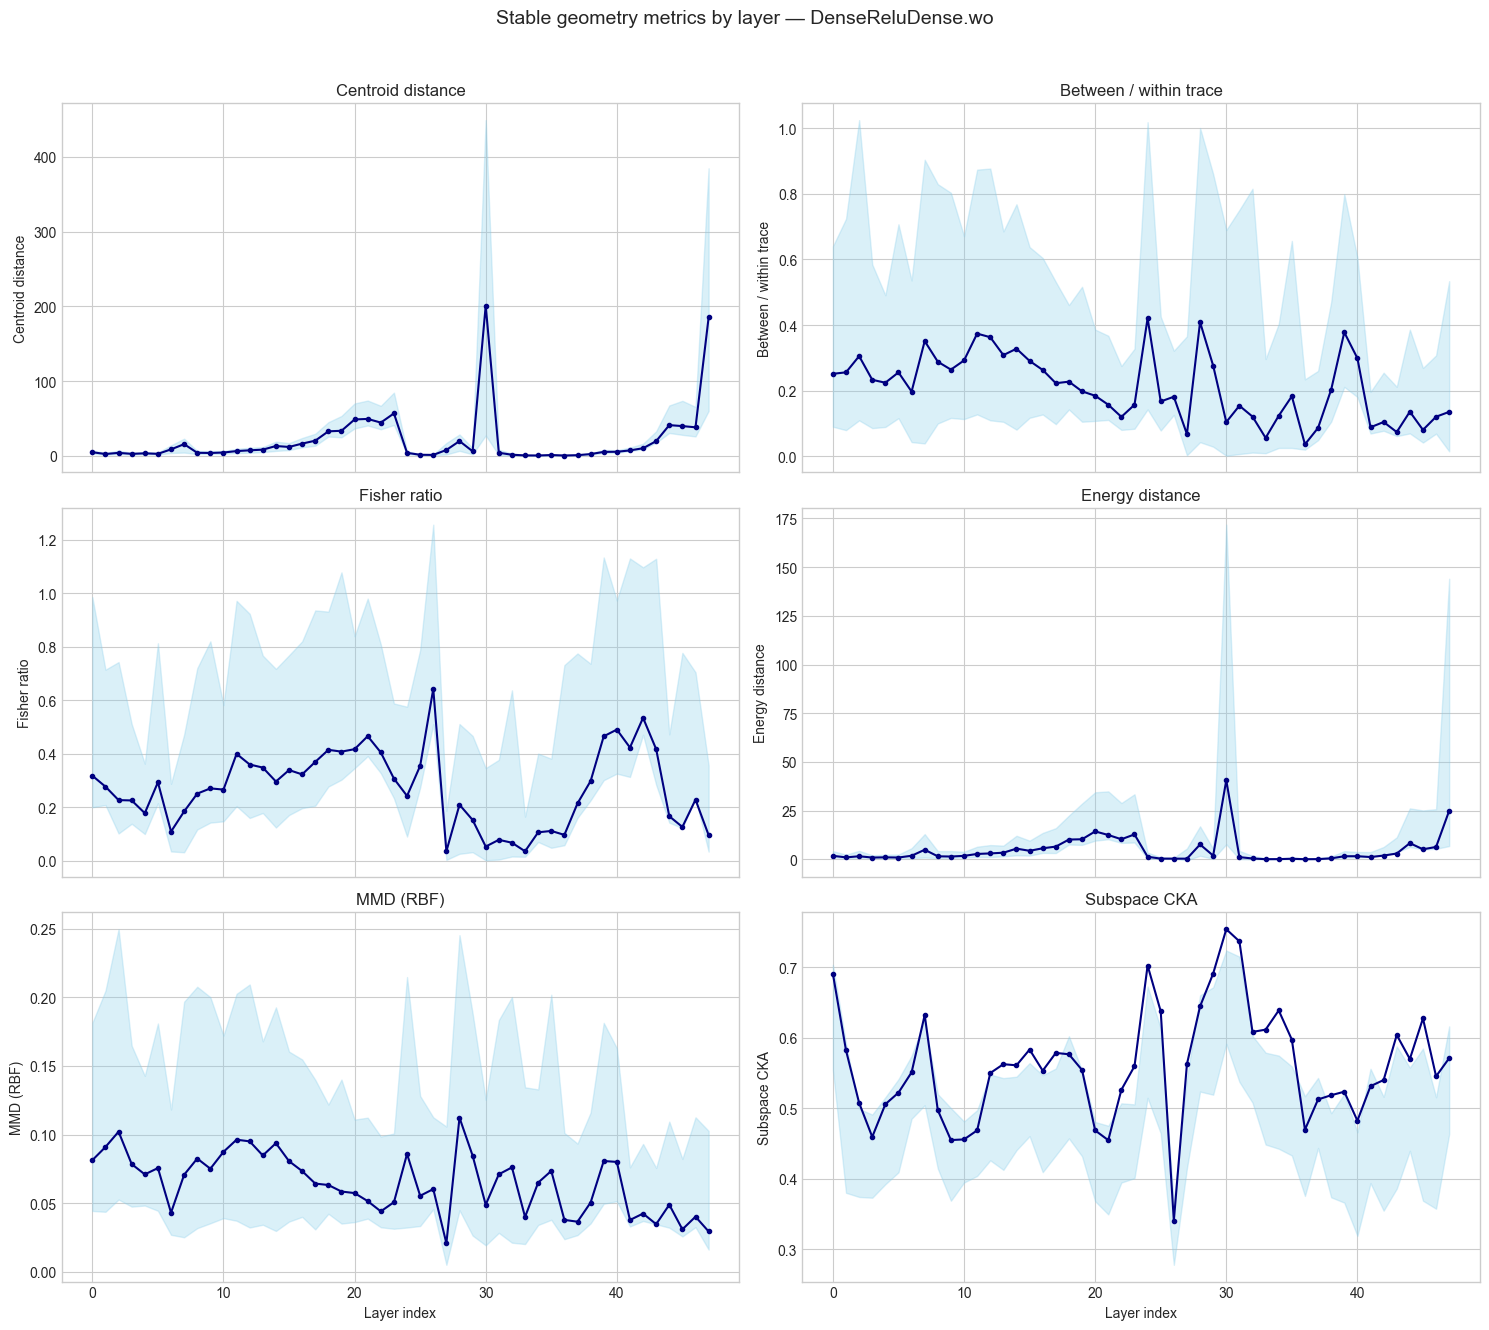

,layer_idx,layer_label,layer_name,centroid_distance_subsample_mean,between_to_within_subsample_mean,fisher_ratio_subsample_mean,energy_distance_subsample_mean,mmd_rbf_subsample_mean,subspace_cka_subsample_mean,mean_principal_angle_deg_subsample_mean
26,26,L26,decoder.T5Block.T5LayerFF.DenseReluDense.wo,1.285847,0.181534,0.642152,0.371630,0.060237,0.340451,58.904423
42,42,L42,decoder.T5Block.T5LayerFF.DenseReluDense.wo,10.216580,0.104543,0.533840,1.954353,0.042399,0.539758,42.828070
40,40,L40,decoder.T5Block.T5LayerFF.DenseReluDense.wo,5.494586,0.299006,0.489808,1.616615,0.080047,0.482086,47.683436
21,21,L21,encoder.T5Block.T5LayerFF.DenseReluDense.wo,49.421612,0.157216,0.465193,12.507281,0.051482,0.454483,49.184532
39,39,L39,decoder.T5Block.T5LayerFF.DenseReluDense.wo,5.322821,0.377918,0.464712,1.604913,0.080709,0.523226,44.981576
41,41,L41,decoder.T5Block.T5LayerFF.DenseReluDense.wo,7.304350,0.088486,0.422731,1.199238,0.037705,0.531076,44.356706
20,20,L20,encoder.T5Block.T5LayerFF.DenseReluDense.wo,48.710553,0.184652,0.416607,14.345988,0.057327,0.468285,48.149535
43,43,L43,decoder.T5Block.T5LayerFF.DenseReluDense.wo,19.704285,0.073946,0.416505,2.994109,0.034660,0.603618,37.984041
18,18,L18,encoder.T5Block.T5LayerFF.DenseReluDense.wo,32.850100,0.227543,0.414132,10.174649,0.063212,0.576269,38.870308
19,19,L19,encoder.T5Block.T5LayerFF.DenseReluDense.wo,33.541847,0.198004,0.407413,10.311087,0.058459,0.553951,42.702039


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True)
x = geometry_df["layer_idx"].to_numpy()

plots = [
    ("centroid_distance_subsample_mean", "centroid_distance_boot_ci_low", "centroid_distance_boot_ci_high", "Centroid distance"),
    ("between_to_within_subsample_mean", "between_to_within_boot_ci_low", "between_to_within_boot_ci_high", "Between / within trace"),
    ("fisher_ratio_subsample_mean", "fisher_ratio_boot_ci_low", "fisher_ratio_boot_ci_high", "Fisher ratio"),
    ("energy_distance_subsample_mean", "energy_distance_boot_ci_low", "energy_distance_boot_ci_high", "Energy distance"),
    ("mmd_rbf_subsample_mean", "mmd_rbf_boot_ci_low", "mmd_rbf_boot_ci_high", "MMD (RBF)"),
    ("subspace_cka_subsample_mean", "subspace_cka_boot_ci_low", "subspace_cka_boot_ci_high", "Subspace CKA"),
]

for ax, (mean_col, low_col, high_col, title) in zip(axes.ravel(), plots):
    mean = geometry_df[mean_col].to_numpy()
    low = geometry_df[low_col].to_numpy()
    high = geometry_df[high_col].to_numpy()
    ax.plot(x, mean, color="navy", marker="o", markersize=3)
    ax.fill_between(x, low, high, color="skyblue", alpha=0.3)
    ax.set_title(title)
    ax.set_ylabel(title)

axes[-1, 0].set_xlabel("Layer index")
axes[-1, 1].set_xlabel("Layer index")
plt.suptitle(f"Stable geometry metrics by layer — {LAYER_NAME_FILTER}", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

geometry_df.sort_values("fisher_ratio_subsample_mean", ascending=False)[[
    "layer_idx", "layer_label", "layer_name",
    "centroid_distance_subsample_mean", "between_to_within_subsample_mean",
    "fisher_ratio_subsample_mean", "energy_distance_subsample_mean",
    "mmd_rbf_subsample_mean", "subspace_cka_subsample_mean",
    "mean_principal_angle_deg_subsample_mean",
]].head(12)

In [9]:
def make_auc_pipeline(feature_dim, pca_cap):
    k = min(pca_cap, feature_dim, len(y_all) - 1)
    return Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=max(k, 1), random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
    ])

X_all = np.concatenate([X0, X1], axis=0)
y_all = np.array([0] * len(X0) + [1] * len(X1))
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

per_layer_auc_rows = []
for layer_idx, layer_label in enumerate(layer_labels):
    X_layer = X_all[:, layer_idx, :]
    pipe = make_auc_pipeline(X_layer.shape[1], PER_LAYER_PCA_COMPONENTS)
    scores = cross_validate(pipe, X_layer, y_all, cv=cv, scoring=["roc_auc", "accuracy"], return_train_score=False)
    per_layer_auc_rows.append({
        "layer_idx": layer_idx,
        "layer_label": layer_label,
        "layer_name": layer_names[layer_idx],
        "auc_mean": float(scores["test_roc_auc"].mean()),
        "auc_std": float(scores["test_roc_auc"].std(ddof=1)),
        "acc_mean": float(scores["test_accuracy"].mean()),
        "acc_std": float(scores["test_accuracy"].std(ddof=1)),
    })

per_layer_auc_df = pd.DataFrame(per_layer_auc_rows)
per_layer_auc_df.sort_values("auc_mean", ascending=False).head(10)

,layer_idx,layer_label,layer_name,auc_mean,auc_std,acc_mean,acc_std
3,3,L03,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.860,0.055678,0.77,0.090830
12,12,L12,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.858,0.107331,0.82,0.057009
26,26,L26,decoder.T5Block.T5LayerFF.DenseReluDense.wo,0.856,0.112827,0.79,0.082158
28,28,L28,decoder.T5Block.T5LayerFF.DenseReluDense.wo,0.856,0.101390,0.80,0.061237
13,13,L13,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.846,0.070922,0.76,0.082158
0,0,L00,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.842,0.108950,0.76,0.108397
1,1,L01,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.842,0.099850,0.76,0.119373
7,7,L07,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.834,0.085615,0.74,0.082158
24,24,L24,decoder.T5Block.T5LayerFF.DenseReluDense.wo,0.834,0.029665,0.81,0.065192
32,32,L32,decoder.T5Block.T5LayerFF.DenseReluDense.wo,0.832,0.135351,0.80,0.100000


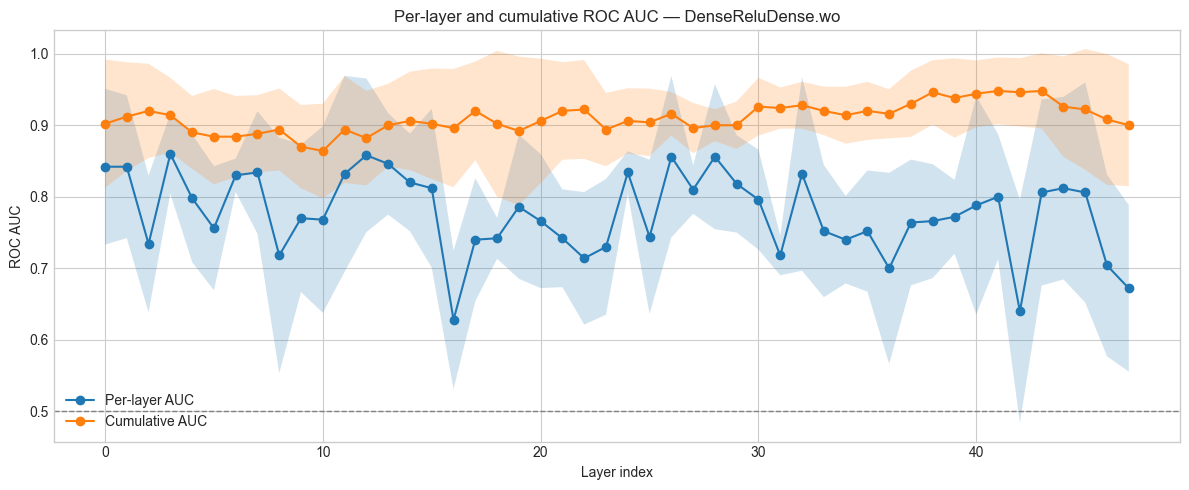

In [10]:
def cumulative_features(X, up_to_layer):
    return X[:, :up_to_layer, :].reshape(X.shape[0], -1)

cum_rows = []
for k in range(1, X_all.shape[1] + 1):
    X_cum = cumulative_features(X_all, k)
    pipe = make_auc_pipeline(X_cum.shape[1], CUMULATIVE_PCA_COMPONENTS)
    scores = cross_validate(pipe, X_cum, y_all, cv=cv, scoring=["roc_auc"], return_train_score=False)
    cum_rows.append({
        "layer_idx": k - 1,
        "layer_label": layer_labels[k - 1],
        "auc_mean": float(scores["test_roc_auc"].mean()),
        "auc_std": float(scores["test_roc_auc"].std(ddof=1)),
    })

cumulative_auc_df = pd.DataFrame(cum_rows)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(per_layer_auc_df["layer_idx"], per_layer_auc_df["auc_mean"], marker="o", label="Per-layer AUC")
ax.fill_between(per_layer_auc_df["layer_idx"], per_layer_auc_df["auc_mean"] - per_layer_auc_df["auc_std"], per_layer_auc_df["auc_mean"] + per_layer_auc_df["auc_std"], alpha=0.2)
ax.plot(cumulative_auc_df["layer_idx"], cumulative_auc_df["auc_mean"], marker="o", label="Cumulative AUC")
ax.fill_between(cumulative_auc_df["layer_idx"], cumulative_auc_df["auc_mean"] - cumulative_auc_df["auc_std"], cumulative_auc_df["auc_mean"] + cumulative_auc_df["auc_std"], alpha=0.2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Per-layer and cumulative ROC AUC — {LAYER_NAME_FILTER}")
ax.set_xlabel("Layer index")
ax.set_ylabel("ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
def aligned_trajectory_distance(traj, proto):
    return float(np.linalg.norm(traj - proto, axis=1).mean())

def cosine_distance(a, b):
    return 1.0 - float(np.dot(a, b) / max(np.linalg.norm(a) * np.linalg.norm(b), 1e-12))

def dtw_trajectory_distance(traj, proto):
    n, m = len(traj), len(proto)
    dp = np.full((n + 1, m + 1), np.inf)
    dp[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = cosine_distance(traj[i - 1], proto[j - 1])
            dp[i, j] = cost + min(dp[i - 1, j], dp[i, j - 1], dp[i - 1, j - 1])
    return float(dp[n, m] / (n + m))

def cross_validated_prototype_auc(X, y, use_dtw=False):
    scores = np.zeros(len(X), dtype=float)
    for train_idx, test_idx in cv.split(np.zeros(len(y)), y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        proto0 = X_train[y_train == 0].mean(axis=0)
        proto1 = X_train[y_train == 1].mean(axis=0)
        for pos, idx in enumerate(test_idx):
            traj = X_test[pos]
            if use_dtw:
                d0 = dtw_trajectory_distance(traj, proto0)
                d1 = dtw_trajectory_distance(traj, proto1)
            else:
                d0 = aligned_trajectory_distance(traj, proto0)
                d1 = aligned_trajectory_distance(traj, proto1)
            scores[idx] = d0 - d1
    return float(roc_auc_score(y, scores)), scores

trajectory_auc_aligned, trajectory_scores_aligned = cross_validated_prototype_auc(X_all, y_all, use_dtw=False)
print(f"Prototype trajectory AUC (aligned) : {trajectory_auc_aligned:.4f}")

if RUN_DTW_TRAJECTORY:
    trajectory_auc_dtw, trajectory_scores_dtw = cross_validated_prototype_auc(X_all, y_all, use_dtw=True)
    print(f"Prototype trajectory AUC (DTW)     : {trajectory_auc_dtw:.4f}")

Prototype trajectory AUC (aligned) : 0.6348


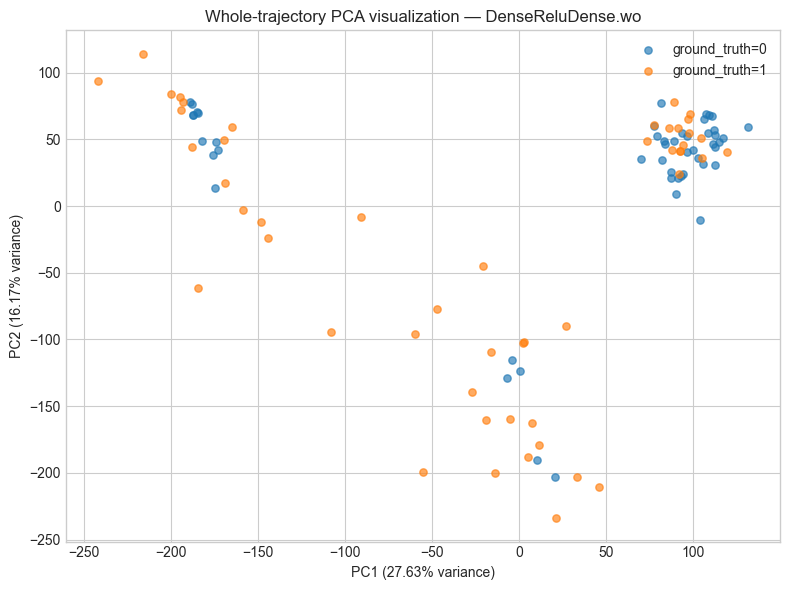

In [12]:
X_flat = X_all.reshape(X_all.shape[0], -1)
traj_pca = PCA(n_components=2, random_state=RANDOM_STATE)
traj_proj = traj_pca.fit_transform(StandardScaler().fit_transform(X_flat))
traj_var = traj_pca.explained_variance_ratio_ * 100.0

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(traj_proj[y_all == 0, 0], traj_proj[y_all == 0, 1], alpha=0.65, label=LABEL_0, s=28)
ax.scatter(traj_proj[y_all == 1, 0], traj_proj[y_all == 1, 1], alpha=0.65, label=LABEL_1, s=28)
ax.set_title(f"Whole-trajectory PCA visualization — {LAYER_NAME_FILTER}")
ax.set_xlabel(f"PC1 ({traj_var[0]:.2f}% variance)")
ax.set_ylabel(f"PC2 ({traj_var[1]:.2f}% variance)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
summary_df = geometry_df.merge(per_layer_auc_df[["layer_idx", "auc_mean", "auc_std"]], on="layer_idx", how="left")
summary_cols = [
    "layer_idx", "layer_label", "layer_name",
    "auc_mean", "auc_std",
    "centroid_distance_subsample_mean",
    "between_to_within_subsample_mean",
    "fisher_ratio_subsample_mean",
    "energy_distance_subsample_mean",
    "mmd_rbf_subsample_mean",
    "subspace_cka_subsample_mean",
    "mean_principal_angle_deg_subsample_mean",
]

print(f"Aligned whole-trajectory prototype AUC: {trajectory_auc_aligned:.4f}")
display(summary_df[summary_cols].sort_values(["auc_mean", "fisher_ratio_subsample_mean"], ascending=False).head(20))

Aligned whole-trajectory prototype AUC: 0.6348


,layer_idx,layer_label,layer_name,auc_mean,auc_std,centroid_distance_subsample_mean,between_to_within_subsample_mean,fisher_ratio_subsample_mean,energy_distance_subsample_mean,mmd_rbf_subsample_mean,subspace_cka_subsample_mean,mean_principal_angle_deg_subsample_mean
3,3,L03,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.860,0.055678,2.704862,0.233222,0.224849,0.933078,0.078455,0.459148,47.488217
12,12,L12,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.858,0.107331,7.428324,0.363047,0.359265,3.053268,0.095023,0.549662,41.752234
26,26,L26,decoder.T5Block.T5LayerFF.DenseReluDense.wo,0.856,0.112827,1.285847,0.181534,0.642152,0.371630,0.060237,0.340451,58.904423
28,28,L28,decoder.T5Block.T5LayerFF.DenseReluDense.wo,0.856,0.101390,19.774335,0.409035,0.208786,7.646594,0.112292,0.644164,34.286248
13,13,L13,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.846,0.070922,8.338242,0.308456,0.347702,3.417127,0.084748,0.562219,39.889131
0,0,L00,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.842,0.108950,4.848536,0.251398,0.317254,1.817943,0.081323,0.690143,31.455899
1,1,L01,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.842,0.099850,2.510907,0.256043,0.276423,1.023954,0.090918,0.581723,40.051157
24,24,L24,decoder.T5Block.T5LayerFF.DenseReluDense.wo,0.834,0.029665,4.023166,0.420898,0.241684,1.344691,0.085853,0.702109,30.452231
7,7,L07,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.834,0.085615,15.682803,0.351232,0.183701,4.930660,0.070700,0.631936,35.161483
11,11,L11,encoder.T5Block.T5LayerFF.DenseReluDense.wo,0.832,0.137004,6.405234,0.374005,0.398999,2.781467,0.096254,0.468378,48.175174
